## 1. Import and Setup

This section covers the libraries used throughout the project.

- **NumPy** — handles mathematical operations on arrays.
- **Pandas** — handles our CSV dataset of phishing URLs.
- **Matplotlib** — used for plotting graphs and visualizations.
- **Scikit-learn** — we use four components from this library:
  - `model_selection` — automatically splits the data into training and test sets.
  - `linear_model` — provides the sigmoid function used in our logistic regression classifier, rather than building it from scratch.
  - `ensemble` — provides the decision tree model used in our second classifier.
  - `metrics` — provides accuracy score and confusion matrix functions to properly evaluate model performance.
- **XGBoost** — similar to a decision tree, but smarter.Instead of all trees voting equally and taking the majority, each tree learns from the mistakes of the previous one.
- **Warnings** — suppresses unnecessary warning messages from Python during the ML Process.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Data Loading & Exploration

Now we access the csv of data and we read into  a table using the data frame. We print out the first 5 rows.

In [2]:
# This makes us load the dataset using the panda library.
df = pd.read_csv('phishing_site_urls.csv')

# See the first 5 rows of the dataset
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


- We have to get a better understanding of how the data is distributed before building our model the labels, amounts of data whether the data is skewed to one side of the labels or something. In short get a feel of the data before we proceed.


In [3]:
# How many rows and columns do we have in the dataset?
print("Shape:", df.shape)

# What are the column names?
print("Columns:", df.columns.tolist())

# How many of each label do we have?
print("\nLabel counts:")
print(df['Label'].value_counts())

Shape: (549346, 2)
Columns: ['URL', 'Label']

Label counts:
Label
good    392924
bad     156422
Name: count, dtype: int64


- We realize the data shows we have more good URLs than the bad ones. We proceed to change the labels from bad or good to 1 and 0 respectfully. This is the turning point in the whole thing right now. This will serve as our real labels on the data hence forth.


In [4]:
# Convert labels to numbers
# bad = 1 (phishing), good = 0 (legit)
df['Label'] = df['Label'].map({'bad': 1, 'good': 0})

print("Labels after conversion:")
print(df['Label'].value_counts())
print("\nFirst 5 rows:")
df.head()

Labels after conversion:
Label
0    392924
1    156422
Name: count, dtype: int64

First 5 rows:


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,1
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,1
3,mail.printakid.com/www.online.americanexpress....,1
4,thewhiskeydregs.com/wp-content/themes/widescre...,1


## 3. Feature Engineering

Now we are done changing our labels to binary(phishing or non phishing) and all we can now get started to getting the features that play an important role and how we extract them from the URL. The common features associated with phising emails are the following:
1. url_length        → how long is the URL? 
2. num_dots          → how many dots? 
3. has_https         → does it use HTTPS? 
4. has_ip            → does it contain an IP address? 
5. num_slashes       → how many slashes? 
6. has_at            → does it have @ symbol?
7. num_subdomains    → how many subdomains? 
8. has_suspicious    → does it contain words like login/verify/secure?
9. url_entropy       → how random does it look? 
10. num_digits       → how many numbers in the URL?

In [5]:
import re #regular library used for finiding patterns in strings in python 
from urllib.parse import urlparse
from scipy.stats import entropy as scipy_entropy

def extract_features(url):
    features = {}
    
    # 1. URL length
    features['url_length'] = len(url)
    
    # 2. Number of dots
    features['num_dots'] = url.count('.')
    
    # 3. Has HTTPS
    features['has_https'] = 1 if url.startswith('https') else 0
    
    # 4. Has IP address
    features['has_ip'] = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0
    
    # 5. Number of slashes
    features['num_slashes'] = url.count('/')
    
    # 6. Has @ symbol
    features['has_at'] = 1 if '@' in url else 0
    
    # 7. Number of subdomains
    features['num_subdomains'] = len(urlparse(url).netloc.split('.')) - 2
    
    # 8. Has suspicious words
    suspicious_words = ['login', 'verify', 'secure', 'account', 'update', 'confirm']
    features['has_suspicious'] = 1 if any(word in url.lower() for word in suspicious_words) else 0
    
    # 9. URL entropy
    counts = [url.count(c) for c in set(url)]
    features['url_entropy'] = scipy_entropy(counts)
    
    # 10. Number of digits
    features['num_digits'] = sum(c.isdigit() for c in url)
    
    return features
print("Feature extraction function defined!")

Feature extraction function defined!


- Before applying to the full dataset let us test the feature extraction on a sample url.


In [6]:
# Test our feature extractor on one URL
test_url = "http://g00gle.account-verify@sketchy-site.com/login/confirm?user=123"
features = extract_features(test_url)

for feature, value in features.items():
    print(f"{feature}: {value}")

url_length: 68
num_dots: 2
has_https: 0
has_ip: 0
num_slashes: 4
has_at: 1
num_subdomains: 1
has_suspicious: 1
url_entropy: 3.2424915620283636
num_digits: 5


## 4. Data Preparation
- Now that the result in the URL above was as expected we can proceed to now make it for the entire dataset of phishing emails we had in the first place.

In [7]:
# Apply feature extraction to all URLs
print("Extracting features from all URLs... this may take a minute")

features_df = df['URL'].apply(lambda url: pd.Series(extract_features(url)))
# Explanation of the above code: it takes the 'URL' column from the dataframe df and applies the extract_features function to each URL. 
# The result is a new dataframe features_df where each row corresponds to the features extracted from a URL.
print("Done!")
print("Features shape:", features_df.shape)
features_df.head()

Extracting features from all URLs... this may take a minute
Done!
Features shape: (549346, 10)


,url_length,num_dots,has_https,has_ip,num_slashes,has_at,num_subdomains,has_suspicious,url_entropy,num_digits
0,225.0,6.0,0.0,0.0,10.0,0.0,-1.0,1.0,3.484372,58.0
1,81.0,5.0,0.0,0.0,4.0,0.0,-1.0,0.0,3.248700,1.0
2,177.0,7.0,0.0,0.0,11.0,0.0,-1.0,1.0,3.272378,47.0
3,60.0,6.0,0.0,0.0,2.0,0.0,-1.0,0.0,2.827931,0.0
4,116.0,1.0,0.0,0.0,10.0,0.0,-1.0,0.0,3.194475,21.0


- We now define the features and the associated labels that we got with them. we have X for features (10 of them) and y labels (just 0 or 1).

In [8]:
# Define X (features) and y (labels)
X = features_df
y = df['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (549346, 10)
y shape: (549346,)


- Ok now we all set and good we have a data frame with features and we still need the original df since it contains the actual ouput( is 0 or 1 for is a good url or phising url respectively). Now we can work on splitting the data following our model of 80% train data and 20% test data. before we proceed to training.


In [9]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # makes the split reproducible
    stratify=y          # keeps the same good/bad ratio in both splits
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (439476, 10)
X_test shape: (109870, 10)
y_train shape: (439476,)
y_test shape: (109870,)


## 5. Model Training & Evaluation

- We can now proceed to the training of the model. We will train with a bunch of models in mind and then we will compare these models and pick the best

 ### 5.1 Logistic Regression

- Now the exciting part is the training of the model we have to minimize the loss as much as possible by through gradient descent. We assume abritrary weights for all features as well as a bias and we use the sklearn library to perfrom the gradient descent and the training in general for us this is the best way to proceed as the sk library hides the complexity behind the entire process of training. Emphasis on how we used the standard scaler to normalize the data so that some do not have higher importance than others due to their value rather we just give them a particular range of values  that is the same for all features and we are all good. We dont scale before the seperation into train and test because there will be data leakage and the model wil learn the standard deviation and the mean overall. so technically having a sneak peek in to the test data 

In [10]:
# Train Logistic Regression
from sklearn.preprocessing import StandardScaler

# Scale the features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.7939


### Understanding the Results that Are Below 

- **Precision** — when the model flags a URL as phishing, 
  how often is it actually phishing?

- **Recall** — out of all actual phishing URLs, 
  how many did our model catch?

- **F1-Score** — balance between precision and recall. 
  A low F1 means the model is failing on one of them.

- **Support** — how many URLs of each type exist in the test set.

For a phishing detector, **recall is the most critical metric** — 
missing a phishing URL means a Lebanese user gets hacked.
Our logistic regression recall of 0.30 means 70% of phishing 
URLs slip through, which motivates us to try stronger models.

In [11]:
# Detailed evaluation of Logistic Regression
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.99      0.87     78585
           1       0.94      0.30      0.45     31285

    accuracy                           0.79    109870
   macro avg       0.86      0.64      0.66    109870
weighted avg       0.82      0.79      0.75    109870


Confusion Matrix:
[[77980   605]
 [22042  9243]]


> - Our model was so low on its recall when it flagged a URL as phishing it got it right 94% of the time and this is good but it missed about 70% of the phishing emails this is a grave issue despite having a 79% accuracy this is not still the best model for this problem mostlikely due to the fact that the data is skewed towards a higher number of legits or good emails than phishing URLs.

   ### 5.2 Random Forest
  Now we have to try the random model and seee if using the decision trees give better results overall 

In [12]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Phishing']))

Random Forest Accuracy: 0.8623

Classification Report:
              precision    recall  f1-score   support

       Legit       0.88      0.93      0.91     78585
    Phishing       0.79      0.70      0.74     31285

    accuracy                           0.86    109870
   macro avg       0.84      0.81      0.82    109870
weighted avg       0.86      0.86      0.86    109870



> - As you can see there is a fanisating improvement from the 0.30 to 0.70 on the recall so most of the phishing URLs are now being realized this is a great jump. We went from catching 30% to catching 70% of the URLs which are labelled as phishing. 

This line of code below is of no importance specifically to this model at this stage. It will be used later in our agentic approach in solving this issue. Pickle is used to load into our agent without retraining our agent from scratch every single time. since the agent has its own python file on its own.

In [29]:
import pickle

# Save the best model for the agent
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved as rf_model.pkl ✅")

Model saved as rf_model.pkl ✅


  ### 5.3 XGBoost 
  Now that we have done the one with the decision tree( random forest) we are going to use an advacned model that rather than voting and we assume the highest result is the right output, we will make sure that the next model makes a decision based on the mistakes of the previous 

In [13]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Phishing']))

XGBoost Accuracy: 0.8513

Classification Report:
              precision    recall  f1-score   support

       Legit       0.85      0.96      0.90     78585
    Phishing       0.85      0.58      0.69     31285

    accuracy                           0.85    109870
   macro avg       0.85      0.77      0.80    109870
weighted avg       0.85      0.85      0.84    109870



> Random Forest wins on recall (0.70 vs 0.58). That's surprising — XGBoost usually beats Random Forest. <br>


 Why did this happen? A few possible reasons:<br>
XGBoost with default settings isn't tuned for imbalanced data<br>
Random Forest's parallel voting works better for THIS specific dataset

## 6. Model Comparison & Feature Importance

We visualize the performance of all three models across 
accuracy, recall, and F1-score to identify the best performer. Also we find out which feature the best performing found as most important or key to distinguishing between both of htem them.

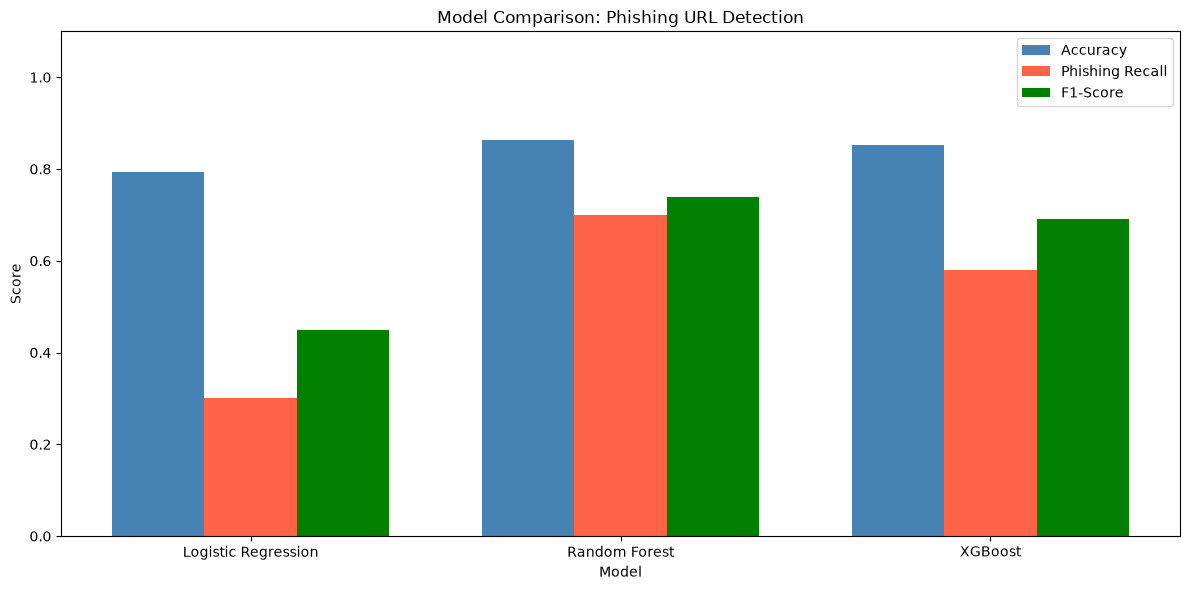

Chart saved!


In [14]:
# Model comparison visualization
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [acc_lr, acc_rf, acc_xgb]
recall = [0.30, 0.70, 0.58]
f1 = [0.45, 0.74, 0.69]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x, recall, width, label='Phishing Recall', color='tomato')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='green')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Phishing URL Detection')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("Chart saved!")

Logistic Regression → high accuracy, terrible recall (red bar tiny)<br>
Random Forest       → best overall, especially recall (red bar tallest)<br>
XGBoost             → good accuracy but recall drops vs Random Forest

> Overall the best model is the one with the random forest. best accuracy and recall rivalled by none.

- Now let us findout which features of the URL the random forest found as key to distinguishing between phishing URLs and good ones 

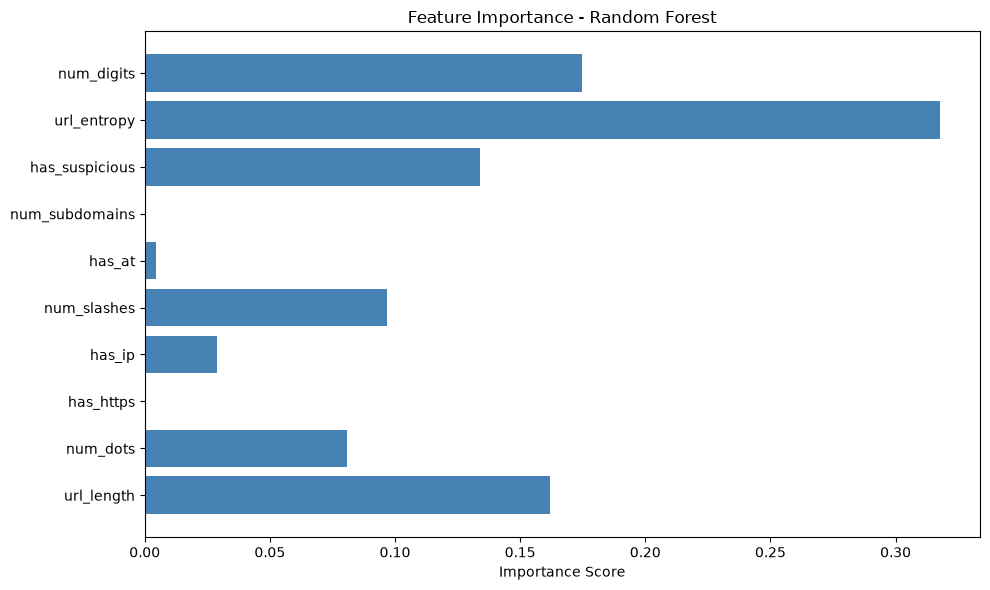

In [15]:
# Feature importance from Random Forest
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

> It turns out the URL entropy is one of the key features in distinguishing the phishing URLs from none phishing. Subdomain has no influence as well as https presence. USELESS FEATURES 

## 7. Neural network Multilayer perceptron 
Random forest gave us 70% recall using the ensemble model. Now let us try the neural network multilayer Perceptron. This will help us recognize complex patterns we couldnt see before. We use ReLu activation between hidden layers to capture non linear patterns. We willuse pytorch Tensors here since they help us track gradients directly that will be used in back propagation easily rather than the Numpy array.

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train.values)
y_test_tensor = torch.FloatTensor(y_test.values)

print("Tensors created successfully!")
print("X_train tensor shape:", X_train_tensor.shape)

Tensors created successfully!
X_train tensor shape: torch.Size([439476, 10])


Now we define our multilayer architecture we go from 64 nodes to seee the complex non linear patterns then to 32 and finally to the 1 output which is converted into a probability by the sigmoid function at the end of it all. the perfect number of nodes not so much to cause overfitting not too little to cause underfitting

In [17]:
class PhishingMLP(nn.Module):
    def __init__(self):
        super(PhishingMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Create an instance of the model
model_mlp = PhishingMLP()
print(model_mlp)

PhishingMLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


Now we work on training our model we developped. using our architecture on the training data set.

In [18]:
# Training setup
pos_weight = torch.tensor([392924/156422])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.001)

dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print("Training setup done!")
print(f"Number of batches per epoch: {len(dataloader)}")

Training setup done!
Number of batches per epoch: 1717


We go through in batches of 256 given we already know that the training data set was 439476/256 that gives the 1717 epoch.

In [19]:
# Train the MLP
epochs = 30

for epoch in range(epochs):
    model_mlp.train()
    total_loss = 0
    
    for batch_X, batch_y in dataloader:
        # Forward pass
        predictions = model_mlp(batch_X).squeeze()
        loss = criterion(predictions, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch 1/30 - Loss: 0.6914
Epoch 2/30 - Loss: 0.6410
Epoch 3/30 - Loss: 0.6290
Epoch 4/30 - Loss: 0.6236
Epoch 5/30 - Loss: 0.6201
Epoch 6/30 - Loss: 0.6177
Epoch 7/30 - Loss: 0.6161
Epoch 8/30 - Loss: 0.6145
Epoch 9/30 - Loss: 0.6129
Epoch 10/30 - Loss: 0.6118
Epoch 11/30 - Loss: 0.6106
Epoch 12/30 - Loss: 0.6096
Epoch 13/30 - Loss: 0.6088
Epoch 14/30 - Loss: 0.6077
Epoch 15/30 - Loss: 0.6073
Epoch 16/30 - Loss: 0.6063
Epoch 17/30 - Loss: 0.6059
Epoch 18/30 - Loss: 0.6054
Epoch 19/30 - Loss: 0.6050
Epoch 20/30 - Loss: 0.6041
Epoch 21/30 - Loss: 0.6037
Epoch 22/30 - Loss: 0.6031
Epoch 23/30 - Loss: 0.6027
Epoch 24/30 - Loss: 0.6023
Epoch 25/30 - Loss: 0.6016
Epoch 26/30 - Loss: 0.6016
Epoch 27/30 - Loss: 0.6015
Epoch 28/30 - Loss: 0.6010
Epoch 29/30 - Loss: 0.6005
Epoch 30/30 - Loss: 0.6004

Training complete!


We can see how much the loss dropped in the process of back propagation or minimizing the gradients.

Now we analyze our model performance by seeing the recall in it.

In [20]:
# Evaluate MLP
model_mlp.eval()

with torch.no_grad():
    y_pred_mlp = torch.sigmoid(model_mlp(X_test_tensor).squeeze())
    y_pred_mlp = (y_pred_mlp > 0.5).float()

y_pred_mlp_np = y_pred_mlp.numpy()

print(f"MLP Accuracy: {accuracy_score(y_test, y_pred_mlp_np):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_np, target_names=['Legit', 'Phishing']))

MLP Accuracy: 0.8058

Classification Report:
              precision    recall  f1-score   support

       Legit       0.89      0.83      0.86     78585
    Phishing       0.63      0.76      0.69     31285

    accuracy                           0.81    109870
   macro avg       0.76      0.79      0.77    109870
weighted avg       0.82      0.81      0.81    109870



In [21]:
# Evaluate MLP
model_mlp.eval()

with torch.no_grad():
    y_pred_mlp = model_mlp(X_test_tensor).squeeze()
    y_pred_mlp = (y_pred_mlp > 0.5).float()

y_pred_mlp_np = y_pred_mlp.numpy()

print(f"MLP Accuracy: {accuracy_score(y_test, y_pred_mlp_np):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_np, target_names=['Legit', 'Phishing']))

MLP Accuracy: 0.8412

Classification Report:
              precision    recall  f1-score   support

       Legit       0.86      0.92      0.89     78585
    Phishing       0.77      0.64      0.70     31285

    accuracy                           0.84    109870
   macro avg       0.82      0.78      0.79    109870
weighted avg       0.84      0.84      0.84    109870



This is the updated comparison chart including the neural network model.

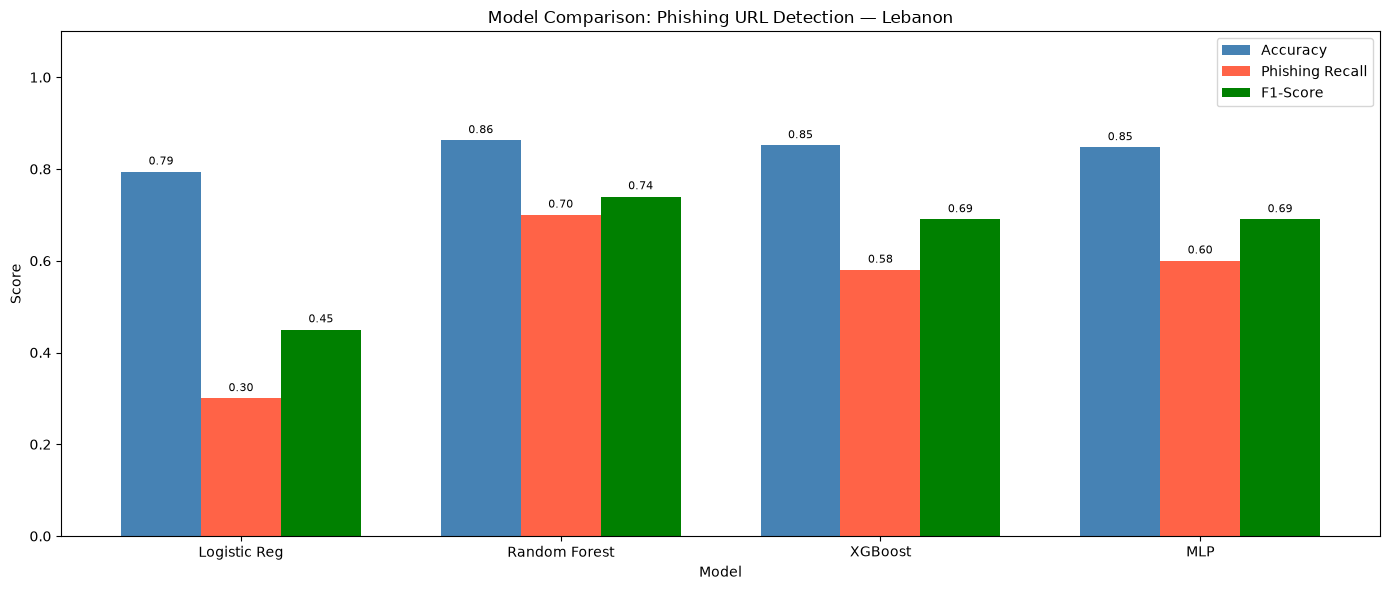

In [22]:
# Updated model comparison including MLP
models = ['Logistic Reg', 'Random Forest', 'XGBoost', 'MLP']
accuracy = [0.7939, 0.8623, 0.8513, 0.8470]
recall = [0.30, 0.70, 0.58, 0.60]
f1 = [0.45, 0.74, 0.69, 0.69]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x, recall, width, label='Phishing Recall', color='tomato')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='green')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Phishing URL Detection — Lebanon')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 8. Transformer
Given the fact that the neural Network did not out perform our random forest we will try to use a transformer that rather than having its features already noted will just go through the url and find patterns on its own. The key aspect here is the attention of the transformer which is very important

In [23]:
# Step 1: Build character-level tokenizer for URLs
# Only keep printable ASCII characters
import string

valid_chars = string.printable  # all printable ASCII characters
chars = sorted(list(set(valid_chars)))
vocab_size = len(chars) + 2  # +2 for padding and unknown

# Character to index mapping
stoi = {ch: i+2 for i, ch in enumerate(chars)}
stoi['<PAD>'] = 0
stoi['<UNK>'] = 1

# Index to character mapping
itos = {i: ch for ch, i in stoi.items()}

print(f"Vocabulary size: {vocab_size}")
print(f"Sample chars: {chars[:20]}")

Vocabulary size: 102
Sample chars: ['\t', '\n', '\x0b', '\x0c', '\r', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']


Now we encode the URLs as we prepare the transformer

In [24]:
# Step 2: Encode URLs as sequences of character indices
MAX_LEN = 200  # max URL length, longer URLs get truncated

def encode_url(url):
    # Convert each character to its index
    encoded = [stoi.get(ch, 1) for ch in url[:MAX_LEN]]  # 1 = UNK for unknown chars
    # Pad with zeros if URL is shorter than MAX_LEN
    padded = encoded + [0] * (MAX_LEN - len(encoded))
    return padded

# Encode all URLs
print("Encoding URLs...")
X_urls = df['URL'].apply(encode_url).tolist()
X_urls = torch.tensor(X_urls, dtype=torch.long)
y_urls = torch.tensor(df['Label'].values, dtype=torch.float)

print(f"X_urls shape: {X_urls.shape}")
print(f"y_urls shape: {y_urls.shape}")

Encoding URLs...
X_urls shape: torch.Size([549346, 200])
y_urls shape: torch.Size([549346])


Now we split into train and test data

In [25]:
# Step 3: Train/test split for transformer
from sklearn.model_selection import train_test_split

X_url_train, X_url_test, y_url_train, y_url_test = train_test_split(
    X_urls, y_urls,
    test_size=0.2,
    random_state=42
)

print(f"X_url_train: {X_url_train.shape}")
print(f"X_url_test:  {X_url_test.shape}")

X_url_train: torch.Size([439476, 200])
X_url_test:  torch.Size([109870, 200])


Now we build the transformer we need no masking here since we are actually just reading the entire URL not predicting anything. And we model and train it all in one 

In [26]:
# Transformer — self-contained (class + model + training)

import time

seq_len = X_url_train.shape[1]
print(f"seq_len={seq_len}, vocab_size={vocab_size}, max_token={X_url_train.max().item()}")

class URLTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, embed_dim=64, num_heads=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=128,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(embed_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0)
        x = self.embedding(x) + self.pos_embedding(positions)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.sigmoid(self.classifier(x))

# built from the data itself — size mismatch impossible
transformer_model = URLTransformer(vocab_size=vocab_size, max_len=seq_len)

SUBSET = 30000
url_dataset = TensorDataset(X_url_train[:SUBSET], y_url_train[:SUBSET])
url_dataloader = DataLoader(url_dataset, batch_size=128, shuffle=True)

transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001)
transformer_criterion = nn.BCELoss()

for epoch in range(3):
    transformer_model.train()
    total_loss, t0 = 0, time.time()
    for batch_X, batch_y in url_dataloader:
        loss = transformer_criterion(transformer_model(batch_X).squeeze(), batch_y)
        transformer_optimizer.zero_grad()
        loss.backward()
        transformer_optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/3 - Loss: {total_loss/len(url_dataloader):.4f} - {time.time()-t0:.0f}s")

print("\nTransformer training complete!")

seq_len=200, vocab_size=102, max_token=101
Epoch 1/3 - Loss: 0.4605 - 394s
Epoch 2/3 - Loss: 0.3692 - 215s
Epoch 3/3 - Loss: 0.3398 - 168s

Transformer training complete!


Evaluation of transformer model 

In [27]:
# Evaluate Transformer (batched to avoid running out of memory)
transformer_model.eval()

preds = []
with torch.no_grad():
    for i in range(0, len(X_url_test), 512):
        batch = X_url_test[i:i+512]
        out = transformer_model(batch).squeeze()
        preds.append((out > 0.5).float())

y_pred_transformer_np = torch.cat(preds).numpy()

print(f"Transformer Accuracy: {accuracy_score(y_url_test, y_pred_transformer_np):.4f}")
print("\nClassification Report:")
print(classification_report(y_url_test, y_pred_transformer_np, target_names=['Legit', 'Phishing']))

Transformer Accuracy: 0.8458

Classification Report:
              precision    recall  f1-score   support

       Legit       0.84      0.96      0.90     78670
    Phishing       0.85      0.55      0.67     31200

    accuracy                           0.85    109870
   macro avg       0.85      0.76      0.78    109870
weighted avg       0.85      0.85      0.83    109870



This is the comparison of every model so far 

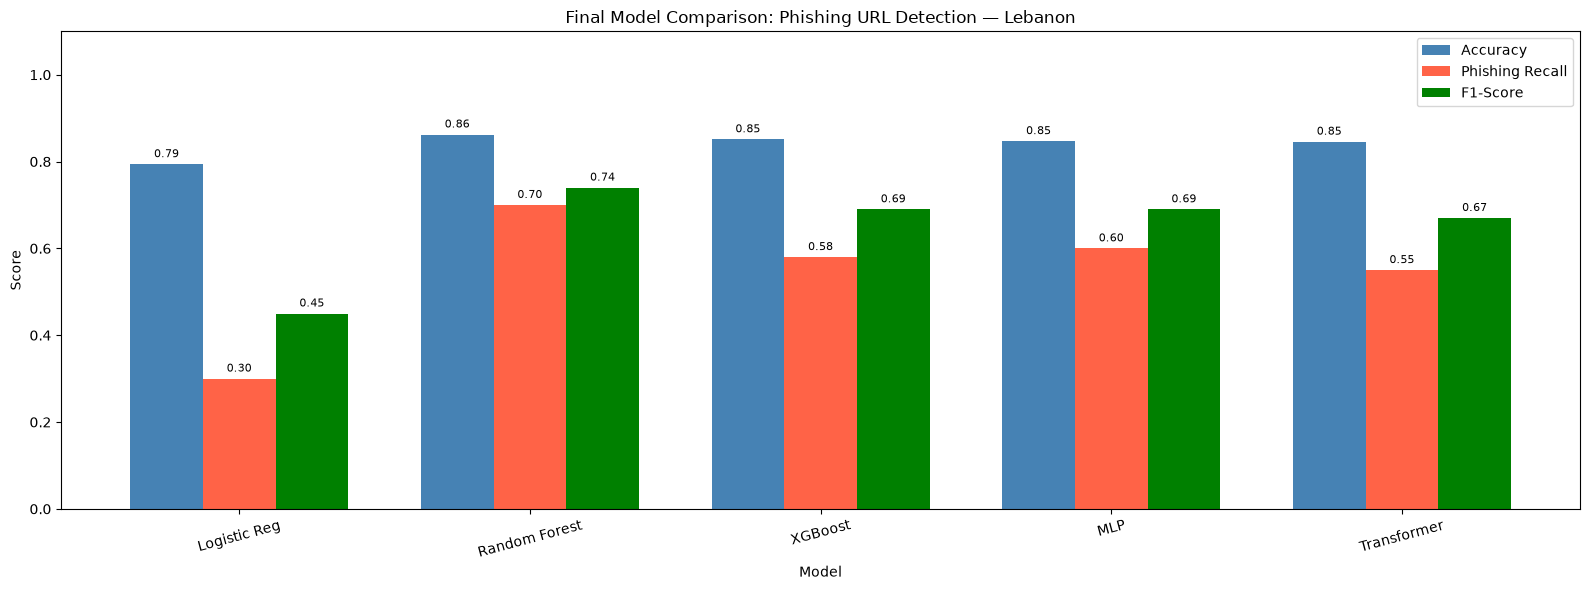

In [28]:
# Final model comparison
models = ['Logistic Reg', 'Random Forest', 'XGBoost', 'MLP', 'Transformer']
accuracy = [0.7939, 0.8623, 0.8513, 0.8470, 0.8458]
recall = [0.30, 0.70, 0.58, 0.60, 0.55]
f1 = [0.45, 0.74, 0.69, 0.69, 0.67]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x, recall, width, label='Phishing Recall', color='tomato')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='green')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison: Phishing URL Detection — Lebanon')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150)
plt.show()